In [68]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

from uni2ts.model.moirai import MoiraiForecast
from uni2ts.model.moirai.module import MoiraiModule

In [69]:
df = pd.read_csv("../data/processed/monthly_labor_market.csv")

df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")

df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

TARGET = "EMPLOY"

split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df = df.iloc[split:split+12]

y_true = test_df[TARGET].values

In [70]:
module = MoiraiModule.from_pretrained("Salesforce/moirai-1.1-R-small")

model = MoiraiForecast(
    prediction_length=12,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
    context_length=module.max_seq_len,   # use pretrained config
    module=module
)

model.eval()

print("past_length:", model.past_length)

past_length: 524


In [71]:
series = train_df[TARGET].values.astype(float)

required_len = model.past_length
series = series[-required_len:]

series = torch.tensor(series, dtype=torch.float32)\
    .unsqueeze(0)\
    .unsqueeze(-1)

print(series.shape)

torch.Size([1, 524, 1])


In [72]:
series = train_df[TARGET].values.astype(float)

required_len = model.past_length
series = series[-required_len:]

series = torch.tensor(series, dtype=torch.float32)\
    .unsqueeze(0)\
    .unsqueeze(-1)

print(series.shape)

torch.Size([1, 524, 1])


In [78]:
past_observed_target = torch.ones_like(series, dtype=torch.bool)

past_is_pad = torch.zeros(
    series.shape[0],
    series.shape[1],
    dtype=torch.bool
)

In [79]:
with torch.no_grad():
    output = model(
        series,
        past_observed_target,
        past_is_pad
    )

print("Output shape:", output.shape)

Output shape: torch.Size([1, 100, 12])


In [87]:
# average over samples
moirai_pred = output.mean(dim=1).squeeze(0).numpy()

print("Forecast shape:", moirai_pred.shape)
print("Forecast:", moirai_pred)

Forecast shape: (12,)
Forecast: [137212.45 137225.05 137291.97 141889.61 138168.44 139257.6  138702.5
 138736.05 138072.56 138474.69 138828.2  139308.14]


In [88]:
moirai_mae = mean_absolute_error(y_true, moirai_pred)
print("Moirai MAE:", moirai_mae)

Moirai MAE: 793.7005208333334


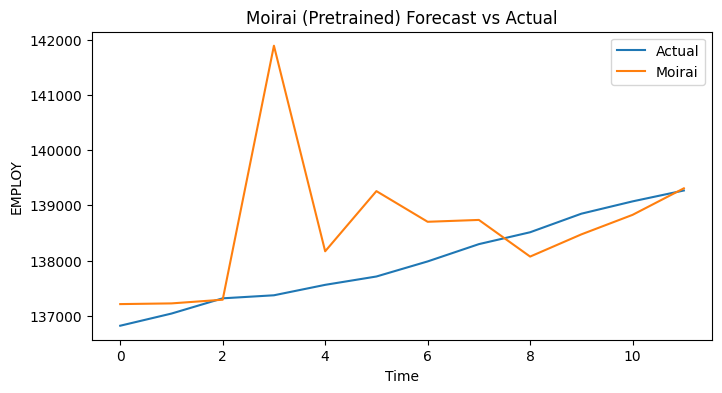

In [89]:
plt.figure(figsize=(8,4))

plt.plot(range(len(y_true)), y_true, label="Actual")
plt.plot(range(len(moirai_pred)), moirai_pred, label="Moirai")

plt.legend()
plt.title("Moirai (Pretrained) Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel(TARGET)

plt.show()

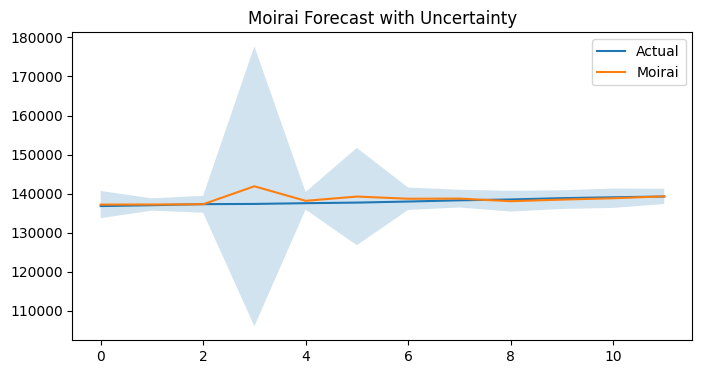

In [91]:
moirai_std = output.std(dim=1).squeeze(0).numpy()

plt.figure(figsize=(8,4))

plt.plot(y_true, label="Actual")
plt.plot(moirai_pred, label="Moirai")

plt.fill_between(
    range(len(moirai_pred)),
    moirai_pred - moirai_std,
    moirai_pred + moirai_std,
    alpha=0.2
)

plt.legend()
plt.title("Moirai Forecast with Uncertainty")

plt.show()